In [ ]:
#We are working with 17 classes now in both detection algorithm and classifier

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

BASE_DIR = r"C:/Users/DM77/Documents/FruitVisionRT/data/classification_v2"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 17
EPOCHS = 50


In [3]:
train_datagen = ImageDataGenerator(rescale=1. / 255)
val_test_datagen = ImageDataGenerator(rescale=1. / 255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

CLASS_INDICES = train_gen.class_indices
CLASS_NAMES = list(CLASS_INDICES.keys())

print("Detected Classes and Indices:")
for class_name, index in CLASS_INDICES.items():
    print(f"  {index}: {class_name}")

Found 47044 images belonging to 17 classes.
Found 5888 images belonging to 17 classes.
Found 5890 images belonging to 17 classes.
Detected Classes and Indices:
  0: apple
  1: avocado
  2: banana
  3: bell pepper
  4: carrot
  5: cucumber
  6: grapes
  7: kiwi
  8: lemon
  9: mango
  10: orange
  11: pear
  12: pineapple
  13: pomegranate
  14: strawberry
  15: tomato
  16: watermelon


In [4]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][0]']           

In [5]:
checkpoint_cb = ModelCheckpoint("best_clv2_model.h5", save_best_only=True, monitor="val_accuracy", mode="max")
earlystop_cb = EarlyStopping(patience=7, restore_best_weights=True)

In [6]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, earlystop_cb]
)


Epoch 1/50
1471/1471 [==============================] - 188s 123ms/step - loss: 0.8032 - accuracy: 0.7475 - val_loss: 0.5604 - val_accuracy: 0.8208
Epoch 2/50
1471/1471 [==============================] - 25s 17ms/step - loss: 0.5812 - accuracy: 0.8135 - val_loss: 0.5147 - val_accuracy: 0.8361
Epoch 3/50
1471/1471 [==============================] - 25s 17ms/step - loss: 0.5555 - accuracy: 0.8213 - val_loss: 0.5294 - val_accuracy: 0.8280
Epoch 4/50
1471/1471 [==============================] - 24s 16ms/step - loss: 0.5371 - accuracy: 0.8277 - val_loss: 0.5134 - val_accuracy: 0.8327
Epoch 5/50
1471/1471 [==============================] - 24s 16ms/step - loss: 0.5440 - accuracy: 0.8258 - val_loss: 0.4943 - val_accuracy: 0.8453
Epoch 6/50
1471/1471 [==============================] - 22s 15ms/step - loss: 0.5322 - accuracy: 0.8270 - val_loss: 0.5227 - val_accuracy: 0.8353
Epoch 7/50
1471/1471 [==============================] - 21s 14ms/step - loss: 0.5323 - accuracy: 0.8302 - val_loss: 0.4975

In [10]:
# Unfreeze top layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [12]:
# loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

In [18]:
#lower learning rae
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
model.compile(
    optimizer=Adam(learning_rate=3e-6),  # or keep 5e-6 if working well
    loss=CategoricalCrossentropy(label_smoothing=0.5),
    metrics=['accuracy']
)


In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("clv2_mobilenetv2_smooth05_v2.h5", save_best_only=True)


# Retrain
fine_tune_epochs = 60
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=fine_tune_epochs,
    callbacks=[earlystop, checkpoint]
)

Epoch 1/60
1471/1471 [==============================] - 25s 16ms/step - loss: 2.1178 - accuracy: 0.9613 - val_loss: 2.1188 - val_accuracy: 0.9365
Epoch 2/60
1471/1471 [==============================] - 22s 15ms/step - loss: 2.1168 - accuracy: 0.9612 - val_loss: 2.1175 - val_accuracy: 0.9367
Epoch 3/60
1471/1471 [==============================] - 22s 15ms/step - loss: 2.1142 - accuracy: 0.9631 - val_loss: 2.1159 - val_accuracy: 0.9390
Epoch 4/60
1471/1471 [==============================] - 23s 15ms/step - loss: 2.1116 - accuracy: 0.9658 - val_loss: 2.1147 - val_accuracy: 0.9394
Epoch 5/60
1471/1471 [==============================] - 22s 15ms/step - loss: 2.1099 - accuracy: 0.9662 - val_loss: 2.1133 - val_accuracy: 0.9407
Epoch 6/60
1471/1471 [==============================] - 22s 15ms/step - loss: 2.1076 - accuracy: 0.9673 - val_loss: 2.1119 - val_accuracy: 0.9399
Epoch 7/60
1471/1471 [==============================] - 23s 15ms/step - loss: 2.1062 - accuracy: 0.9681 - val_loss: 2.1108 -

In [ ]:
#Wow this model does an impressive job at an accuracy of 99% and validation accuracy at around 95-96%

In [20]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")
#we have to test

185/185 [==============================] - 20s 107ms/step - loss: 2.0749 - accuracy: 0.9569
Test Accuracy: 95.69%


In [ ]:
#Test accuracy of 95.7%

In [22]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Get only the class labels actually present in the test set
present_classes = np.unique(y_true)
present_class_names = [k for k, v in test_gen.class_indices.items() if v in present_classes]

# Print classification report
print(classification_report(y_true, y_pred, labels=present_classes, target_names=present_class_names))


185/185 [==============================] - 2s 13ms/step
              precision    recall  f1-score   support

       apple       0.97      0.92      0.94       317
     avocado       0.96      0.98      0.97       260
      banana       0.96      0.96      0.96       510
      carrot       0.97      0.93      0.95       270
      grapes       0.98      0.97      0.97       497
        kiwi       0.97      0.98      0.98       353
       lemon       0.91      0.88      0.90       415
       mango       0.95      0.94      0.94       387
      orange       0.92      0.94      0.93       770
        pear       0.97      0.97      0.97       206
 pomegranate       0.94      0.95      0.95       459
  strawberry       1.00      1.00      1.00       435
      tomato       0.97      0.99      0.98       690
  watermelon       0.97      0.97      0.97       321

    accuracy                           0.96      5890
   macro avg       0.96      0.96      0.96      5890
weighted avg       0.96 

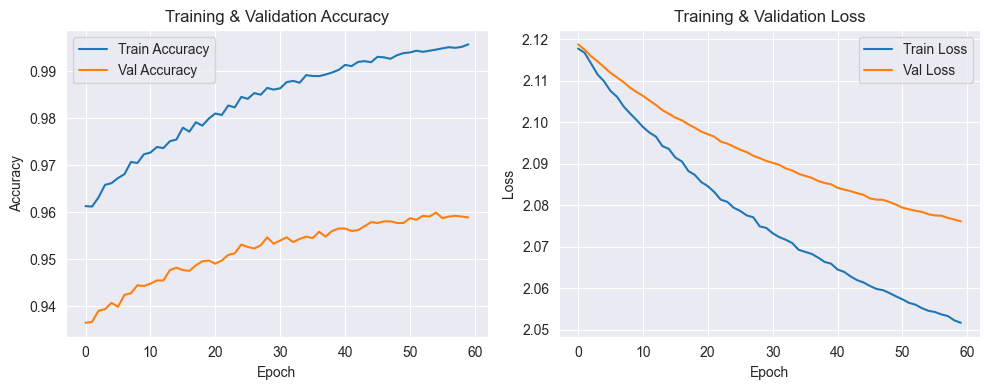

In [23]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Final train and val accuracy
final_train_acc = history_finetune.history['accuracy'][-1]
final_val_acc = history_finetune.history['val_accuracy'][-1]

print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

Final Train Accuracy: 0.9957
Final Validation Accuracy: 0.9589
185/185 [==============================] - 2s 13ms/step - loss: 2.0749 - accuracy: 0.9569
Test Accuracy: 0.9569


In [26]:
# best model
from tensorflow.keras.models import load_model
best_model = load_model("clv2_mobilenetv2_smooth05_v2.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

# Save to file
with open("clv2_mobilenetv2_smooth05_v2.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted and saved as clv2_mobilenetv2_smooth05_v2.tflite")


INFO:tensorflow:Assets written to: C:\Users\DM77\AppData\Local\Temp\tmplqa2by_a\assets


INFO:tensorflow:Assets written to: C:\Users\DM77\AppData\Local\Temp\tmplqa2by_a\assets


Model converted and saved as clv2_mobilenetv2_smooth05_v2.tflite


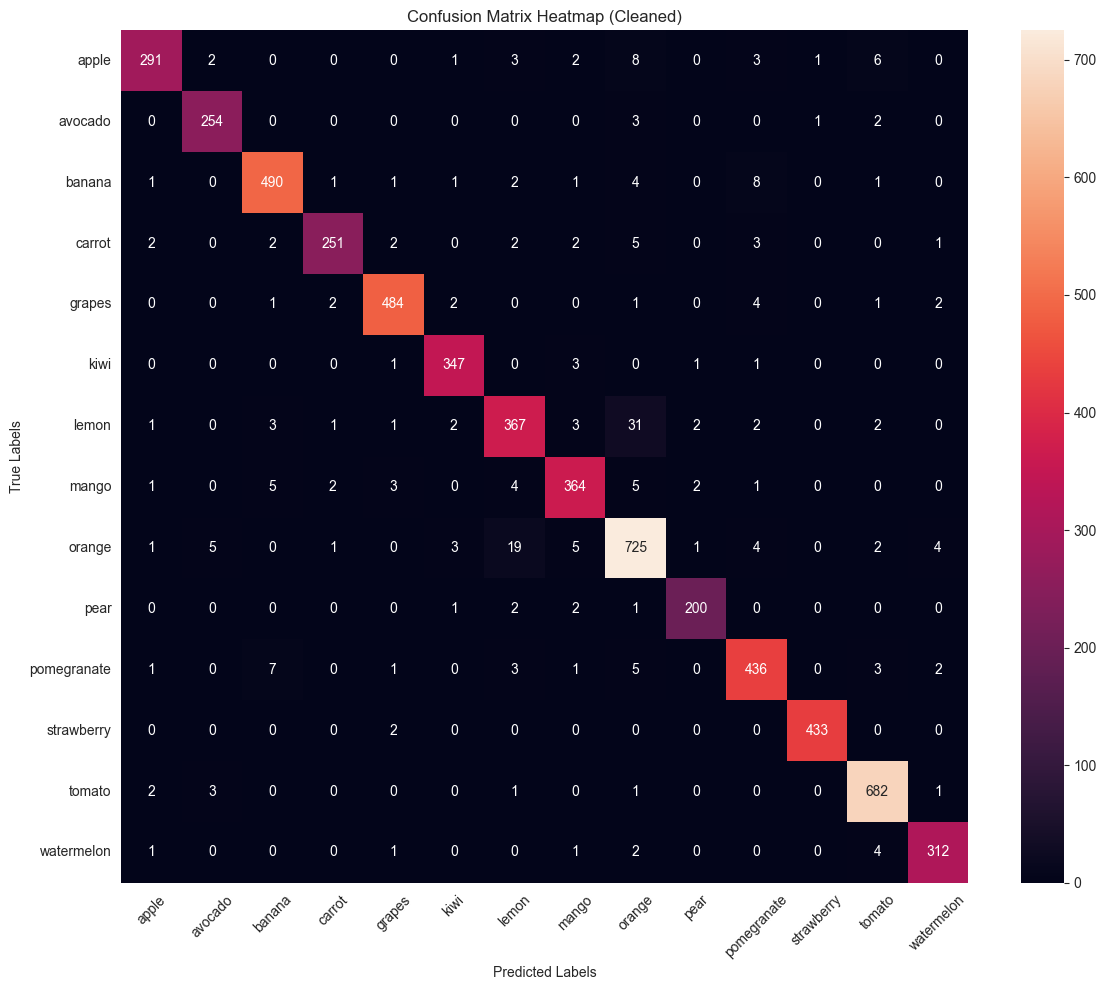

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to numpy arrays
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Get the actual classes present in the test set
present_labels = sorted(np.unique(y_true))
class_names_present = [list(test_gen.class_indices.keys())[i] for i in present_labels]

# Generate confusion matrix only for present classes
cm = confusion_matrix(y_true, y_pred, labels=present_labels)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=class_names_present,
            yticklabels=class_names_present)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap (Cleaned)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


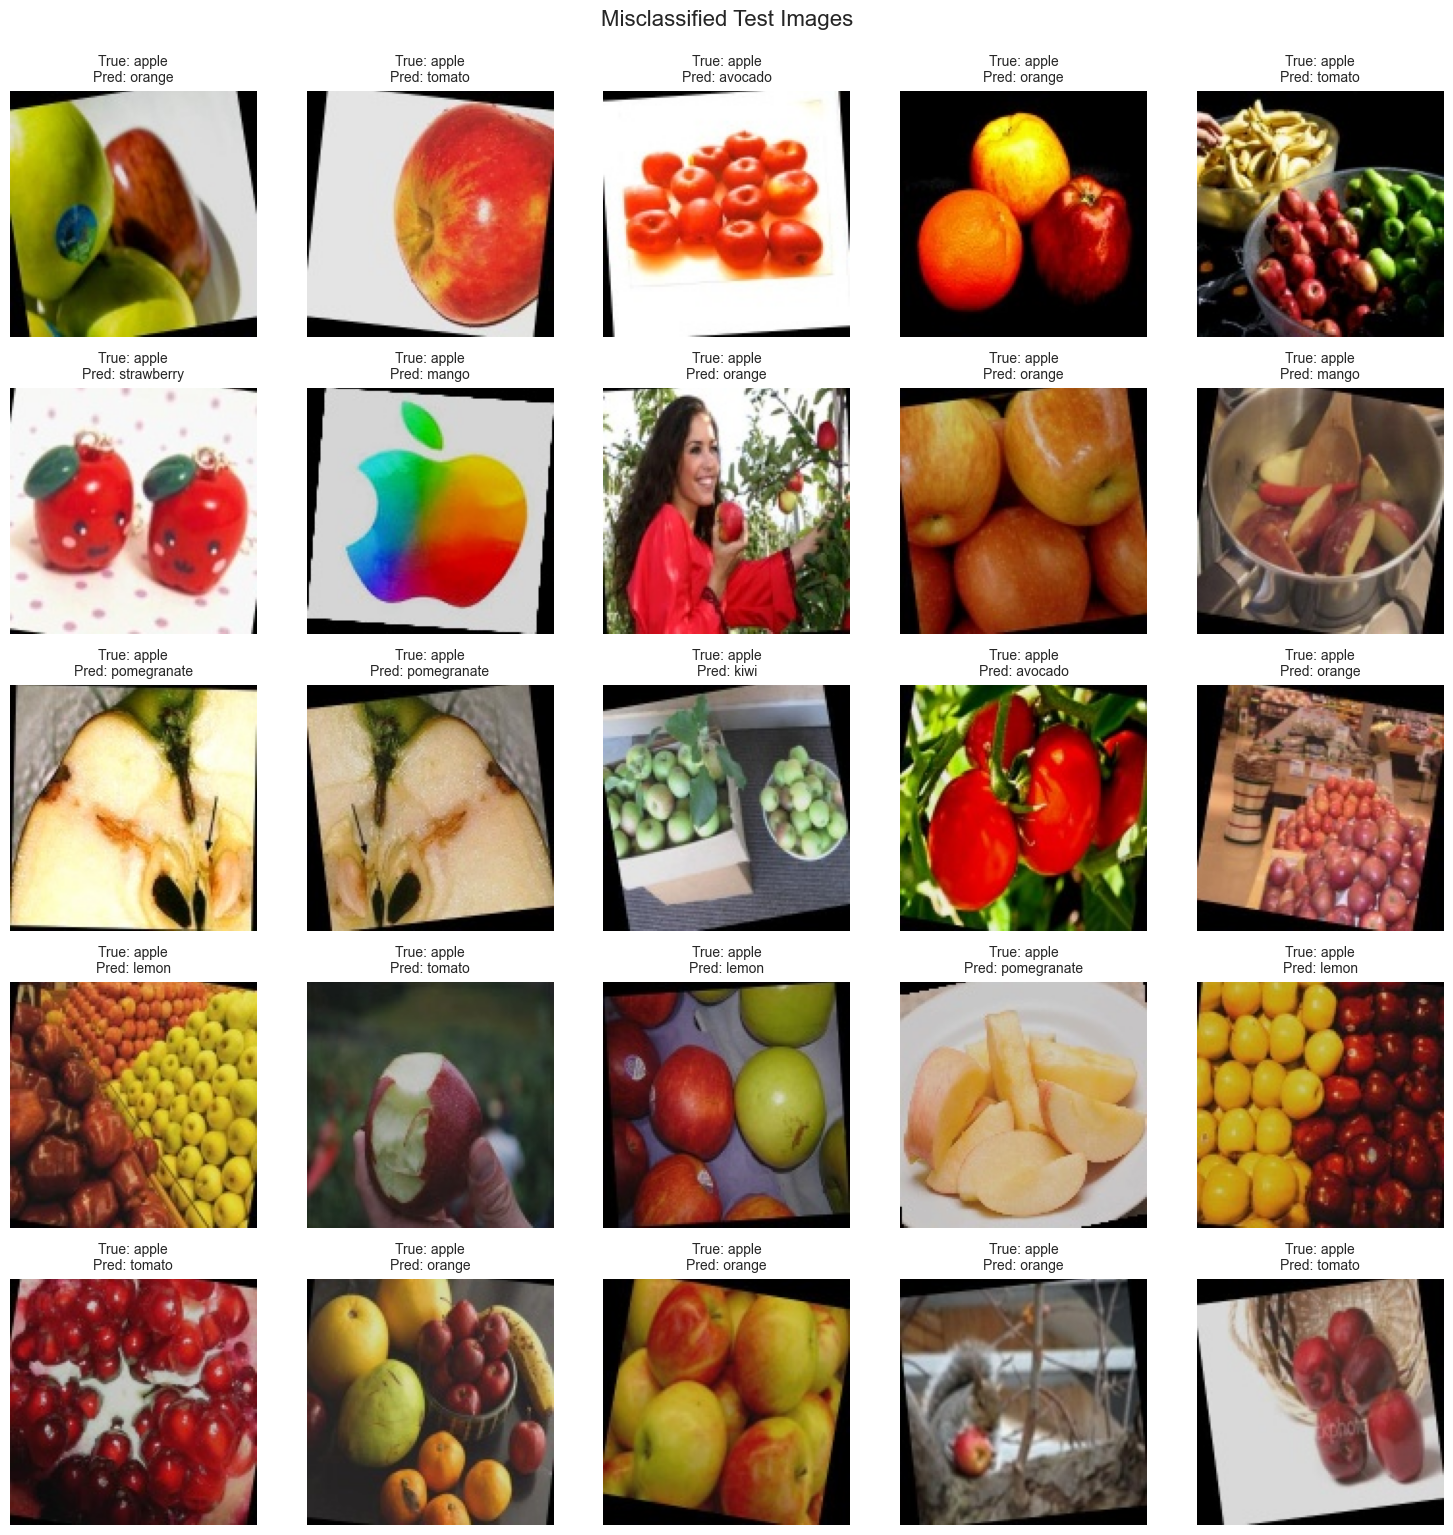

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Get filenames and correct labels
filenames = test_gen.filepaths
wrong = np.where(y_pred != y_true)[0]

# Plot a grid of misclassified images
plt.figure(figsize=(15, 15))
for i, idx in enumerate(wrong[:25]):  # limit to first 25
    img = plt.imread(filenames[idx])
    true_label = class_labels[y_true[idx]]
    pred_label = class_labels[y_pred[idx]]

    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Misclassified Test Images', fontsize=16, y=1.02)
plt.show()

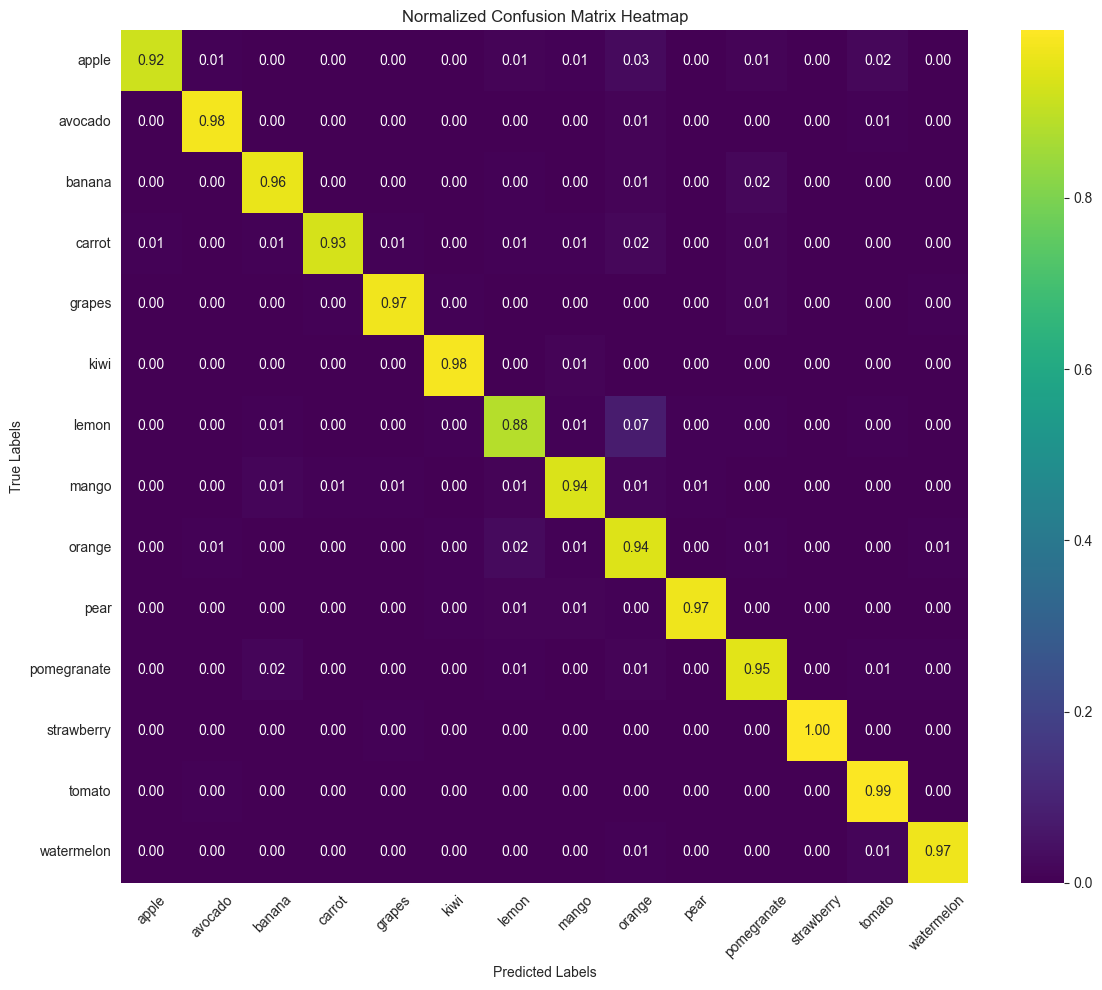

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predicted & true labels
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Filter only present labels
present_labels = sorted(np.unique(y_true))
class_names_present = [list(test_gen.class_indices.keys())[i] for i in present_labels]

# Normalized confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=present_labels, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=class_names_present,
            yticklabels=class_names_present)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

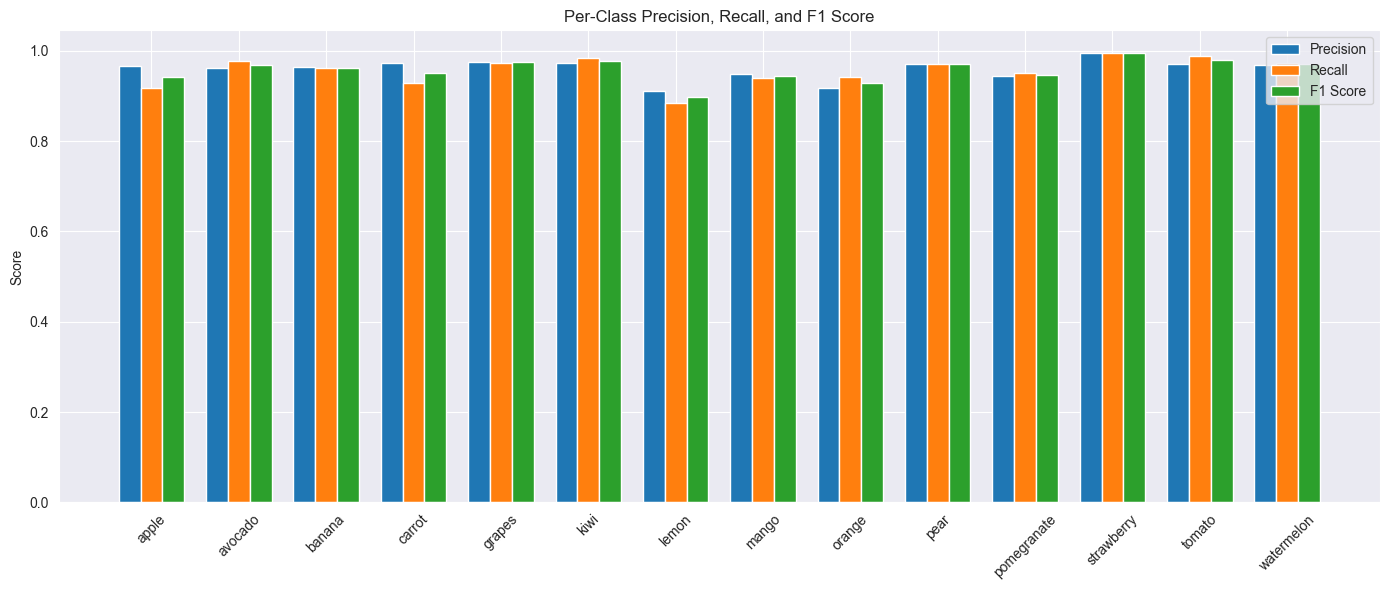

In [31]:
from sklearn.metrics import precision_recall_fscore_support

# Get precision, recall, f1 for present classes
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=present_labels, zero_division=0
)

# Plot bar charts
plt.figure(figsize=(14, 6))

x = np.arange(len(class_names_present))

plt.bar(x - 0.25, precision, width=0.25, label='Precision')
plt.bar(x, recall, width=0.25, label='Recall')
plt.bar(x + 0.25, f1, width=0.25, label='F1 Score')

plt.xticks(ticks=x, labels=class_names_present, rotation=45)
plt.ylabel('Score')
plt.title('Per-Class Precision, Recall, and F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate report as dict
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names_present,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame and save
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv("clv2_classification_report.csv")
print("Classification report saved as clv2_classification_report.csv")


Classification report saved as clv2_classification_report.csv
